# Modulprojekt DLT – Teil B
## Paraphrasenerkennung mit DistilBERT auf MRPC

Dieses Notebook überträgt die Sentiment-Pipeline aus Teil A auf **Satzpaar-Klassifikation**.


## 0 – Einrichtung

In diesem Abschnitt werden die benötigten Bibliotheken installiert, Konstanten wie der Seed, das verwendete Modell und die maximale Eingabelänge festgelegt und geprüft, ob eine GPU verfügbar ist.


In [2]:
# Optional: save results in Google Drive when running in Colab
from google.colab import drive

drive.mount('/content/drive')
RESULTS_DIR = "/content/drive/MyDrive/DLT_MP/results"

Mounted at /content/drive


In [3]:
# In Colab ausführen. Lokal ggf. in einer venv installieren.
%pip install -q "transformers>=4.40" "datasets>=2.19" evaluate scikit-learn peft accelerate
# In Colab ist ein zu altes torchao vorinstalliert, das mit aktuellem peft
# kollidiert (ImportError in Abschnitt 7). LoRA auf BERT braucht torchao nicht,
# daher entfernen wir es. Danach: Laufzeit NICHT neu starten, einfach weiter.
%pip uninstall -y -q torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
# relative path for results
RESULTS_DIR = "results"

In [4]:
import os
import random, numpy as np, torch
import json

SEED = 42
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


## 1 – Datensatz laden und inspizieren

Der **Microsoft Research Paraphrase Corpus (MRPC)** besteht aus Satzpaaren aus Online-Nachrichten und enthält menschliche Annotationen dazu, ob beide Sätze semantisch äquivalent sind.

Hier wird der **MRPC**-Datensatz geladen und hinsichtlich Splits, Klassenverteilung und Eigenschaften der Satzpaare untersucht.





In [5]:
from datasets import load_dataset


ds = load_dataset("nyu-mll/glue", "mrpc")
print(ds)
labels = ds["train"].features["label"].names   # ['not_equivalent', 'equivalent']
print("Labels:", labels)
ds["train"][:2]



README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

mrpc/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  649kB            

mrpc/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mrpc/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 75.7kB            

mrpc/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})
Labels: ['not_equivalent', 'equivalent']


{'sentence1': ['Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
  "Yucaipa owned Dominick 's before selling the chain to Safeway in 1998 for $ 2.5 billion ."],
 'sentence2': ['Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
  "Yucaipa bought Dominick 's in 1995 for $ 693 million and sold it to Safeway for $ 1.8 billion in 1998 ."],
 'label': [1, 0],
 'idx': [0, 1]}

In [6]:
import collections
# Klassenverteilung pro Split
for split in ds:
    c = collections.Counter(ds[split]["label"])
    print(f"{split:11s}: n={len(ds[split]):5d}  not_equivalent={c[0]:5d}  equivalent={c[1]:5d}")

train      : n= 3668  not_equivalent= 1194  equivalent= 2474
validation : n=  408  not_equivalent=  129  equivalent=  279
test       : n= 1725  not_equivalent=  578  equivalent= 1147


Beim MRPC handelt es sich um ein unbalanciertes Datenset. Etwa zwei Drittel der Beispiele sind dem Label `equivalent` zugeordnet, während rund ein Drittel auf `not_equivalent entfällt. Dieses Verhältnis bleibt über die Splits hinweg stabil.

Als Nächstes wird die Länge der Satzpaare untersucht, um `MAX_LENGTH` gegebenenfalls entsprechend anzupassen.

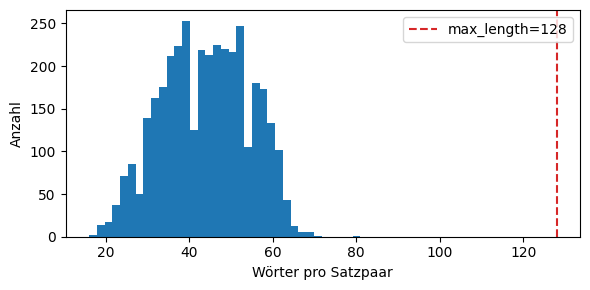

Median: 44  95. Perzentil: 60  Maximum: 81


In [7]:
import matplotlib.pyplot as plt

train_lengths = [len(a.split()) + len(b.split())
                 for a, b in zip(ds["train"]["sentence1"], ds["train"]["sentence2"])]
plt.figure(figsize=(6, 3)); plt.hist(train_lengths, bins=35)
plt.axvline(MAX_LENGTH, color="tab:red", ls="--", label="max_length=128")
plt.xlabel("Wörter pro Satzpaar"); plt.ylabel("Anzahl"); plt.legend()
plt.tight_layout(); plt.show()
print(
    "Median:", int(np.median(train_lengths)),
    " 95. Perzentil:", int(np.percentile(train_lengths,95)),
    " Maximum:", int(np.max(train_lengths))
)

*   50% der Satzpaare bestehen aus 44 oder weniger Wörtern und 50% aus 44 oder mehr.
*   Nur 5% der Satzpaare im Trainingset haben mehr als 60 Wörter.
* Wie kommt man von der Anzahl der Wörter zu der abgeleiteten `MAX_LENGTH der Tokens? Ein Wort könnte ja auch in mehrere Subwort-Tokens zerlegt werden. Deswegen berechne ich die Verteilung nochmal mit dem Tokenizer ohne Truncation:



In [8]:
from transformers import AutoTokenizer
import numpy as np


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_pairs(batch, max_length=None, truncation=False):
  tokens = tokenizer(
      batch["sentence1"],
      batch["sentence2"],
      max_length=max_length,
      truncation=truncation
      )

  tokens["length"] = [len(ids) for ids in tokens["input_ids"]]
  return tokens

tokenized = ds.map(tokenize_pairs, batched=True)

lengths = tokenized["train"]["length"]
print("Median:", np.percentile(lengths, 50))
print("95%:", np.percentile(lengths, 95))
print("Maximum:", np.max(lengths))

# Tokenisierungsbeispiel
print(
    tokenizer.convert_ids_to_tokens(
        tokenized["train"][0]["input_ids"]
    )
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

Median: 53.0
95%: 74.0
Maximum: 103
['[CLS]', 'am', '##ro', '##zi', 'accused', 'his', 'brother', ',', 'whom', 'he', 'called', '"', 'the', 'witness', '"', ',', 'of', 'deliberately', 'di', '##stor', '##ting', 'his', 'evidence', '.', '[SEP]', 'referring', 'to', 'him', 'as', 'only', '"', 'the', 'witness', '"', ',', 'am', '##ro', '##zi', 'accused', 'his', 'brother', 'of', 'deliberately', 'di', '##stor', '##ting', 'his', 'evidence', '.', '[SEP]']


Das 95. Perzentil beim Trainingset liegt bei 74 Tokens und die maximale Tokenanzahl beim Trainingset liegt bei 103 Tokens inklusive Special Tokens "[CLS]" und "[SEP]". `MAX_LENGTH = 128` ist daher eine konservative Wahl: Alle Satzpaare im Trainingsset liegen unterhalb dieser Grenze und können ohne Truncation verarbeitet werden. Eine weitere Reduktion der maximalen Länge wäre zwar möglich, bietet jedoch bei dynamischem Padding nur einen begrenzten Effizienzvorteil.

## 2 – Baselines

Die folgenden Baselines werden verwendetet und an die Satzpaar-Klassifikation von MRPC angepasst:

1. **Majority-Class**
    - trivial, sagt stets die häufigste Trainingsklasse voraus
2. **TF-IDF + logistische Regression**
    - beide Sätze werden separat im gleichen TF-IDF-Merkmalsraum repräsentiert
    - mithilfe der absoluten Differenz und dem elementweisen Produkt der beiden Satzvektoren werden die Unterschiede und lexikalische Gemeinsamkeiten des Satzpaares abgebildet
    - Logistic Regression Classifier lernt anhand dieser Paar-Merkmale





In [9]:
import collections
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score


X1_tr = ds["train"]["sentence1"]
X2_tr = ds["train"]["sentence2"]
ytr   = ds["train"]["label"]

X1_va = ds["validation"]["sentence1"]
X2_va = ds["validation"]["sentence2"]
yva   = ds["validation"]["label"]

# 1) Majority class
maj = collections.Counter(ytr).most_common(1)[0][0]
pred_maj = [maj] * len(yva)
print(
    f"Majority : "
    f"acc={accuracy_score(yva, pred_maj):.3f}  "
    f"macro-F1={f1_score(yva, pred_maj, average='macro'):.3f}"
)
# 2) TF-IDF + LogReg
vec = TfidfVectorizer(ngram_range=(1, 2),min_df=2)
# learn vocabulary from training sentences1 + sentences2
vec.fit(list(X1_tr) + list(X2_tr))
# transform every sentence separately in same vec space
v1_tr = vec.transform(X1_tr)
v2_tr = vec.transform(X2_tr)

v1_va = vec.transform(X1_va)
v2_va = vec.transform(X2_va)

# difference between the sentences
diff_tr = abs(v1_tr - v2_tr)
diff_va = abs(v1_va - v2_va)
# simitarities
prod_tr = v1_tr.multiply(v2_tr)
prod_va = v1_va.multiply(v2_va)
# concatenate both feature types
Xtr_pair = hstack([diff_tr, prod_tr])
Xva_pair = hstack([diff_va, prod_va])
# Log Reg classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr_pair, ytr)
pred_lr = clf.predict(Xva_pair)
print(
    f"TF-IDF+LR: "
    f"acc={accuracy_score(yva, pred_lr):.3f}  "
    f"macro-F1={f1_score(yva, pred_lr, average='macro'):.3f}"
)

Majority : acc=0.684  macro-F1=0.406
TF-IDF+LR: acc=0.735  macro-F1=0.568


Für einen fairen finalen Vergleich werden auch die Baseline-Modelle auf dem Testset evaluiert, sodass alle Modelle anhand derselben Datenbasis verglichen werden.


In [10]:
X1_te = ds["test"]["sentence1"]
X2_te = ds["test"]["sentence2"]
yte   = ds["test"]["label"]

# Majority baseline
pred_maj_test = [maj] * len(yte)

# TF-IDF + Log Reg
v1_te = vec.transform(X1_te)
v2_te = vec.transform(X2_te)

diff_te = abs(v1_te - v2_te)
prod_te = v1_te.multiply(v2_te)

Xte_pair = hstack([diff_te, prod_te])

pred_lr_test = clf.predict(Xte_pair)

print(
    f"Majority TEST: "
    f"acc={accuracy_score(yte, pred_maj_test):.3f}  "
    f"macro-F1={f1_score(yte, pred_maj_test, average='macro'):.3f}"
)

print(
    f"TF-IDF+LR TEST: "
    f"acc={accuracy_score(yte, pred_lr_test):.3f}  "
    f"macro-F1={f1_score(yte, pred_lr_test, average='macro'):.3f}"
)

Majority TEST: acc=0.665  macro-F1=0.399
TF-IDF+LR TEST: acc=0.711  macro-F1=0.575


## 3 – Tokenisierung

Hier wird noch einmal tokenisiert, diesmal mit Truncation und max_length. Dynamisches Padding folgt später.


In [11]:
ds_tok = ds.map(
    tokenize_pairs,
    batched=True,
    fn_kwargs={"max_length": MAX_LENGTH, "truncation": True}
    )

print(tokenizer.convert_ids_to_tokens(ds_tok["train"][0]["input_ids"]))
ds_tok["train"][0].keys()

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

['[CLS]', 'am', '##ro', '##zi', 'accused', 'his', 'brother', ',', 'whom', 'he', 'called', '"', 'the', 'witness', '"', ',', 'of', 'deliberately', 'di', '##stor', '##ting', 'his', 'evidence', '.', '[SEP]', 'referring', 'to', 'him', 'as', 'only', '"', 'the', 'witness', '"', ',', 'am', '##ro', '##zi', 'accused', 'his', 'brother', 'of', 'deliberately', 'di', '##stor', '##ting', 'his', 'evidence', '.', '[SEP]']


dict_keys(['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask', 'length'])

## 4 – Feintuning mit dem `Trainer`

Der Klassifikationskopf wird für MRPC neu initialisiert und anschließend zusammen mit DistilBERT trainiert. Als Auswahlkriterium für den besten Checkpoint wird `macro_f1` auf dem Validation-Split verwendet.

In [12]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0:"not_equivalent",1:"equivalent"},
    label2id={"not_equivalent":0,"equivalent":1}
    )

collator = DataCollatorWithPadding(tokenizer)  # dynamisches Padding pro Batch

def compute_metrics(eval_pred):
    logits, y = eval_pred
    pred = logits.argmax(-1)
    return {"accuracy": accuracy_score(y, pred),
            "macro_f1": f1_score(y, pred, average="macro")}

args = TrainingArguments(
    output_dir="out",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
)
train_result_full = trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.545912,0.407793,0.835784,0.806379
2,0.359962,0.354677,0.850490,0.820401
3,0.247278,0.389397,0.848039,0.813297


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Trainings- und Validierungsmetriken werden gespeichert, um Leistung und Trainingseffizienz später mit LoRA zu vergleichen.

In [13]:
full_eval_history = [
    x for x in trainer.state.log_history
    if "eval_macro_f1" in x
]

full_best_eval = max(full_eval_history, key=lambda x: x["eval_macro_f1"])

full_metrics = {
    "train_loss": train_result_full.metrics["train_loss"],
    "train_runtime": train_result_full.metrics["train_runtime"],
    "train_samples_per_second": train_result_full.metrics["train_samples_per_second"],
    "eval_loss": full_best_eval["eval_loss"],
    "eval_accuracy": full_best_eval["eval_accuracy"],
    "eval_macro_f1": full_best_eval["eval_macro_f1"],
    "best_epoch": full_best_eval["epoch"],
}

## 5 – Evaluation auf dem Test-Set


Das ausgewählte Modell wird abschließend auf dem zuvor unangetasteten Test-Split evaluiert.


DistilBERT test: acc=0.821  macro-F1=0.798

                precision    recall  f1-score   support

not_equivalent       0.74      0.71      0.73       578
    equivalent       0.86      0.88      0.87      1147

      accuracy                           0.82      1725
     macro avg       0.80      0.79      0.80      1725
  weighted avg       0.82      0.82      0.82      1725



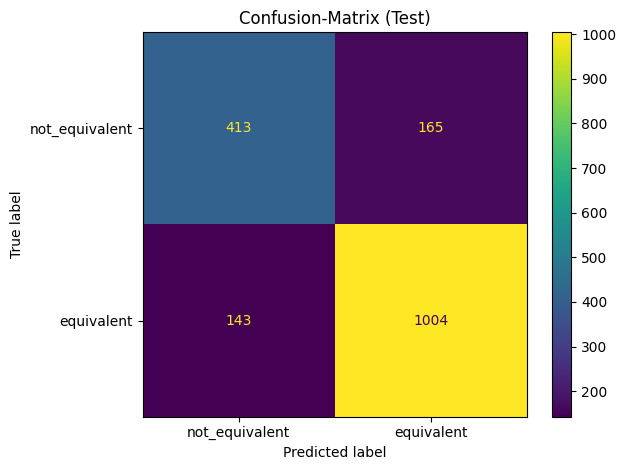

In [22]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pred_out = trainer.predict(ds_tok["test"])
y_true = pred_out.label_ids
y_pred = pred_out.predictions.argmax(-1)

print(f"DistilBERT test: acc={accuracy_score(y_true,y_pred):.3f}  "
      f"macro-F1={f1_score(y_true,y_pred,average='macro'):.3f}\n")
print(classification_report(y_true, y_pred, target_names=labels))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)
plt.title("Confusion-Matrix (Test)"); plt.tight_layout(); plt.show()

Das feinabgestimmte DistilBERT erreicht auf dem Testset **Accuracy 0,821** und **Macro-F1 0,798**. Damit liegt es klar über beiden Baselines (**Majority Macro-F1 0,399; TF-IDF+LR 0,575**).

Die klassenweisen Werte zeigen einen klaren Unterschied: Für `equivalent` liegt F1 bei **0,87**, für `not_equivalent` bei **0,73**.

## 6 – Qualitative Fehleranalyse


Hier werden konkrete Fehlklassifikationen des feinabgestimmten Modells betrachtet. Anhand einzelner Satzpaare werden wiederkehrende Fehlermuster identifiziert um mögliche Ursachen zu erschließen.

In [15]:
test_sent1 = ds["test"]["sentence1"]
test_sent2 = ds["test"]["sentence2"]
errors = [(test_sent1[i], test_sent2[i], labels[y_true[i]], labels[y_pred[i]])
          for i in range(len(y_true)) if y_true[i] != y_pred[i]]
print(f"{len(errors)} Fehler von {len(y_true)} Beispielen\n")
for sent1, sent2, gold, pred in errors[:10]:
    print(f"[gold={gold:14s} | pred={pred:14}]"
          f"\n{'':5s}1. {sent1}"
          f"\n{'':5s}2. {sent2}")

308 Fehler von 1725 Beispielen

[gold=equivalent     | pred=not_equivalent]
     1. The world 's two largest automakers said their U.S. sales declined more than predicted last month as a late summer sales frenzy caused more of an industry backlash than expected .
     2. Domestic sales at both GM and No. 2 Ford Motor Co. declined more than predicted as a late summer sales frenzy prompted a larger-than-expected industry backlash .
[gold=not_equivalent | pred=equivalent    ]
     1. A tropical storm rapidly developed in the Gulf of Mexico Sunday and was expected to hit somewhere along the Texas or Louisiana coasts by Monday night .
     2. A tropical storm rapidly developed in the Gulf of Mexico on Sunday and could have hurricane-force winds when it hits land somewhere along the Louisiana coast Monday night .
[gold=not_equivalent | pred=equivalent    ]
     1. Hong Kong was flat , Australia , Singapore and South Korea lost 0.2-0.4 percent .
     2. Australia was flat , Singapore was down

Das Satzpaar scheint mir falsch annotiert:

>  1. Amgen shares gained 93 cents , or 1.45 percent , to \$ 65.05 in afternoon trading on Nasdaq .
  2. Shares of Allergan were up 14 cents at $ 78.40 in late trading on the New York Stock Exchange .





## 7 – LoRA / Parameter-effizientes Feintuning

Als erste weiterführende Untersuchung wird LoRA mit vollständigem Finetuning verglichen.


In [16]:
from peft import LoraConfig, get_peft_model, TaskType

base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
    target_modules=["q_lin","v_lin"],   # DistilBERT-Attention; bei BERT: ["query","value"]
)
lora_model = get_peft_model(base, lora_cfg)
lora_model.print_trainable_parameters()   # vergleiche mit ~67M des vollen Modells


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [17]:
args_lora = TrainingArguments(
    output_dir="out_lora",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    seed=SEED,
    report_to="none",
)

trainer_lora = Trainer(
    model=lora_model, args=args_lora,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
)
train_result_lora = trainer_lora.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.627607,0.608953,0.683824,0.406114
2,0.610801,0.602032,0.683824,0.406114
3,0.606229,0.599597,0.683824,0.406114


In [18]:
lora_eval_history = [
    x for x in trainer_lora.state.log_history
    if "eval_macro_f1" in x
]
lora_best_eval = max(lora_eval_history, key=lambda x: x["eval_macro_f1"])
lora_metrics = {
    "train_loss": train_result_lora.metrics["train_loss"],
    "train_runtime": train_result_lora.metrics["train_runtime"],
    "train_samples_per_second": train_result_lora.metrics["train_samples_per_second"],
    "eval_loss": lora_best_eval["eval_loss"],
    "eval_accuracy": lora_best_eval["eval_accuracy"],
    "eval_macro_f1": lora_best_eval["eval_macro_f1"],
    "best_epoch": lora_best_eval["epoch"],
}

Full Fine-Tuning und LoRA werden anhand der Validierungsleistung sowie der Trainingseffizienz gegenübergestellt.


In [19]:
import pandas as pd

comparison = pd.DataFrame([
    {"Method": "Full Fine-Tuning", **full_metrics},
    {"Method": "LoRA", **lora_metrics},
])

comparison

,Method,train_loss,train_runtime,train_samples_per_second,eval_loss,eval_accuracy,eval_macro_f1,best_epoch
0,Full Fine-Tuning,0.384384,100.0011,110.039,0.354677,0.850490,0.820401,2.0
1,LoRA,0.614879,66.9976,164.245,0.608953,0.683824,0.406114,1.0


## 8 – Lernkurve

Als zweite Untersuchung wird analysiert, wie stark die Modellleistung von der verfügbaren Trainingsdatenmenge abhängt. Mehrere Trainingsgrößen und Seeds erlauben eine Einschätzung von Daten-Effizienz und Streuung.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '5.574', 'train_samples_per_second': '134.5', 'train_steps_per_second': '8.611', 'train_loss': '0.6398', 'epoch': '3'}
n=  250  seed= 42 
acc=0.699  macro-F1=0.454 



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '86.22', 'train_samples_per_second': '127.6', 'train_steps_per_second': '8.003', 'train_loss': '0.3749', 'epoch': '3'}
n= 3668  seed=123 
acc=0.855  macro-F1=0.817 



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'train_runtime': '86.35', 'train_samples_per_second': '127.4', 'train_steps_per_second': '7.991', 'train_loss': '0.3796', 'epoch': '3'}
n= 3668  seed=456 
acc=0.863  macro-F1=0.826 

n=  250  acc=0.693 ± 0.008  macro-F1=0.436 ± 0.026
n= 1000  acc=0.757 ± 0.043  macro-F1=0.665 ± 0.095
n= 3668  acc=0.859 ± 0.004  macro-F1=0.823 ± 0.005


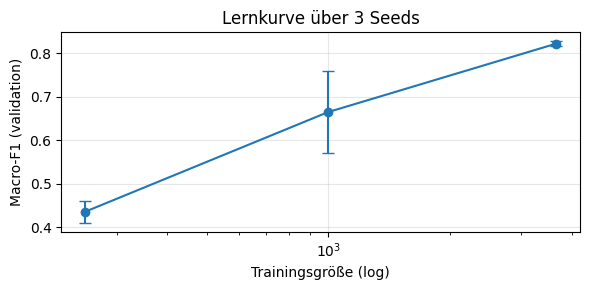

In [20]:
# Lernkurve (Macro-F1 vs. Trainingsgröße).


def train_eval(n_train, seed, epochs=3):
    """Trainiert DistilBERT auf n_train Beispielen und gibt (acc, macro_f1) auf
    dem validation-Split zurück. Nutzt dieselbe Tokenisierung wie oben."""
    set_seed_all(seed)
    sub = (ds_tok["train"].shuffle(seed=seed).select(range(n_train)))

    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        id2label={0:"not_equivalent",1:"equivalent"},
        label2id={"not_equivalent":0,"equivalent":1}
        )

    a = TrainingArguments(
        output_dir=f"out_lc_{n_train}_seed{seed}",
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        eval_strategy="no",       # wir evaluieren einmal am Ende selbst
        save_strategy="no",
        seed=seed,
        report_to="none",
        logging_strategy="no",
        disable_tqdm=True,
    )
    tr = Trainer(model=m, args=a, train_dataset=sub,
                 data_collator=collator, compute_metrics=compute_metrics)
    tr.train()

    out = tr.predict(ds_tok["validation"])
    yp = out.predictions.argmax(-1)
    yt = out.label_ids
    return accuracy_score(yt, yp), f1_score(yt, yp, average="macro")

max_n = len(ds["train"])
sizes = [250, 1000, max_n]
lc = {}
seeds = [42, 123, 456]

for n in sizes:
    lc[n] = []
    for seed in seeds:
        acc, mf1 = train_eval(n, seed=seed)
        lc[n].append({"seed": seed, "accuracy": acc, "macro_f1": mf1})
        print(
            f"n={n:5d}  seed={seed:3d} \n"
            f"acc={acc:.3f}  macro-F1={mf1:.3f} \n"
        )

lc_summary = {}
for n in sizes:
    accs = [run["accuracy"] for run in lc[n]]
    f1s = [run["macro_f1"] for run in lc[n]]
    lc_summary[n] = {
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs, ddof=1),
        "macro_f1_mean": np.mean(f1s),
        "macro_f1_std": np.std(f1s, ddof=1)
    }

    print(
        f"n={n:5d}  "
        f"acc={np.mean(accs):.3f} ± {np.std(accs, ddof=1):.3f}  "
        f"macro-F1={np.mean(f1s):.3f} ± {np.std(f1s, ddof=1):.3f}"
    )

plt.figure(figsize=(6, 3))
plt.errorbar(
    sizes,
    [lc_summary[n]["macro_f1_mean"] for n in sizes],
    yerr=[lc_summary[n]["macro_f1_std"] for n in sizes],
    marker="o",
    capsize=4
)

plt.xscale("log")
plt.xlabel("Trainingsgröße (log)")
plt.ylabel("Macro-F1 (validation)")
plt.title("Lernkurve über 3 Seeds")
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

# Ergebnisse für den Bericht sichern
lc_path = os.path.join(RESULTS_DIR, "learning_curve.json")
with open(lc_path, "w") as f:
    json.dump(lc, f, indent=2)


Die Lernkurve zeigt einen klaren Effekt der Trainingsdatenmenge. Der mittlere Validation-Macro-F1 steigt von **0,436 ± 0,026** bei 250 Beispielen über **0,665 ± 0,095** bei 1.000 Beispielen auf **0,823 ± 0,005** mit allen 3.668 Trainingsbeispielen. Gleichzeitig sinkt die Streuung bei voller Datenmenge stark.

Besonders bei 1.000 Beispielen ist die Seed-Abhängigkeit groß (Standardabweichung 0,095); einzelne Läufe reichen von deutlich schwächeren bis zu bereits guten Ergebnissen.

## 9 – Speichern der Ergebnisse




In [21]:
metrics = {
    "model": MODEL_NAME, "seed": SEED, "max_length": MAX_LENGTH,
    "test_accuracy": float(accuracy_score(y_true, y_pred)),
    "test_macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    "baseline_majority_test_accuracy": float(
        accuracy_score(yte, pred_maj_test)
    ),
    "baseline_majority_test_macro_f1": float(
        f1_score(yte, pred_maj_test, average="macro")
    ),
    "baseline_tfidf_test_accuracy": float(
        accuracy_score(yte, pred_lr_test)
    ),
    "baseline_tfidf_test_macro_f1": float(
        f1_score(yte, pred_lr_test, average="macro")
    ),
}
metrics_path = os.path.join(RESULTS_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

{
  "model": "distilbert-base-uncased",
  "seed": 42,
  "max_length": 128,
  "test_accuracy": 0.8214492753623188,
  "test_macro_f1": 0.7977035757692061,
  "baseline_majority_test_accuracy": 0.664927536231884,
  "baseline_majority_test_macro_f1": 0.3993732590529248,
  "baseline_tfidf_test_accuracy": 0.7107246376811595,
  "baseline_tfidf_test_macro_f1": 0.5745159904678532
}
